In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from fewjaxexplore.amplitude.ampinterp import get_amplitude_interpolant
from fewjaxexplore.amplitude.ylm import SpinWeightedSphericalHarmonic
from fewjaxexplore.constants import MRSUN_SI, MTSUN_SI, Gpc
from fewjaxexplore.trajectory.ode import get_trajectory_generator
from fewjaxexplore.trajectory.utils import (
    KerrGeoEquatorialCoordinateFrequencies,
    KerrGeoEquatorialCoordinateFrequencyTimeDerivatives,
)

from pygwtf.generator import MultipleHarmonicTimeFrequencyWaveform

jax.config.update("jax_enable_x64", True)

In [2]:
ampint = get_amplitude_interpolant(
    "../../../../jax-study/few/few-jax-study/amps-prep/amp_interp_grid.npy"
)

In [3]:
traj_gen, pdot_interp, edot_interp = get_trajectory_generator(
    "../../../../jax-study/few/few-jax-study/amps-prep/KerrEccEqFluxData.h5",
    return_interpolants=True,
)

In [275]:
# Define the parameters for the time-frequency grid
dT = 86400 / 4  # 6 hours # SFT time.
nT = 365 * 4  # 1 year # Number of SFT time bins in the total observation
dt = 5  # time step for the *time-domain* data -> used to determine fmax for the SFT
dF = 1 / dT  # Frequency spacing within the SFT.
# 1/(2*dt) is the Nyquist frequency for the time-domain data
fmax = 1 / (2 * dt)  # Nyquist frequency for the time-domain data

nF = (
    int((fmax) / dF) + 1
)  # Number of frequency bins needed to cover the Nyquist frequency.

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 10,  # Number of frequency bins to use in the fresnel kernel
}

generator = MultipleHarmonicTimeFrequencyWaveform(
    config, backend="cpu", tdi_type=2
)

Spacecraft orbits not supplied. Falling back to analytic orbits
Spacecraft light travel times not supplied. Falling back to analytic calculation


In [ ]:
m1 = 1e6
m2 = 1e1
a = 0.1
p0 = 10.0
e0 = 0.1
dist = 1.0
Phi_phi0 = 0.45
Phi_r0 = 0.3
theta = jnp.pi / 3

T = 1

# n_modes = jnp.r_[jnp.arange(-15, 16), jnp.arange(-15, 16)]
# l_modes = jnp.ones_like(n_modes) * 2
# l_modes = l_modes.at[n_modes.size // 2:].set(3)
# m_modes = l_modes.copy()

l_modes = []
m_modes = []
n_modes = []

for ell in range(2, 4):
    for m in range(ell, ell + 1):
        for n in range(-10, 11):
            l_modes.append(ell)
            m_modes.append(m)
            n_modes.append(n)

l_modes = jnp.array(l_modes)
m_modes = jnp.array(m_modes)
n_modes = jnp.array(n_modes)

# n_modes = jnp.arange(-15, 16)
# l_modes = jnp.ones_like(n_modes) * 3
# m_modes = l_modes.copy()

In [296]:
t_tranche_eval = generator.t_tranche + dT / 2

In [297]:
def get_phi_f_fdot_amp_for_modes(
    t_tranche_eval,
    m1,
    m2,
    a,
    p0,
    e0,
    Phi_phi0,
    Phi_r0,
    theta,
    dist,
    T,
    l_modes,
    m_modes,
    n_modes,
):
    Msec = (m1 + m2) * MTSUN_SI
    mu = m1 * m2 / (m1 + m2)
    nu = mu / (m1 + m2)
    traj_sol = traj_gen(m1, m2, a, p0, e0, Phi_phi0, Phi_r0, T)
    p, e, Phi_phi, Phi_r = jax.vmap(traj_sol.evaluate)(t_tranche_eval / Msec).T
    ylms_pos_m = jax.vmap(
        SpinWeightedSphericalHarmonic, in_axes=(0, 0, None, None)
    )(l_modes, m_modes, theta, -jnp.pi / 2)
    ylms_neg_m = (
        jax.vmap(SpinWeightedSphericalHarmonic, in_axes=(0, 0, None, None))(
            l_modes, -m_modes, theta, -jnp.pi / 2
        )
        * (-1) ** l_modes
    )
    ylms = jnp.stack([ylms_pos_m, ylms_neg_m], axis=-1)

    amplitudes = (
        jax.vmap(ampint, in_axes=(None, 0, 0, None, None, None))(
            a, p, e, l_modes, m_modes, n_modes
        )
    ).T
    phases = (
        Phi_phi[None, :] * m_modes[:, None] + Phi_r[None, :] * n_modes[:, None]
    ) + jnp.unwrap(jnp.angle(amplitudes), axis=-1)
    amplitudes = jnp.abs(amplitudes) * (mu * MRSUN_SI / dist / Gpc)

    Omega_phi, Omega_r = jax.vmap(
        KerrGeoEquatorialCoordinateFrequencies, in_axes=(None, 0, 0, None)
    )(a, p, e, 1.0).T
    f_phi = Omega_phi / (2 * jnp.pi * Msec)
    f_r = Omega_r / (2 * jnp.pi * Msec)
    frequencies = (
        f_phi[None, :] * m_modes[:, None] + f_r[None, :] * n_modes[:, None]
    )

    Omega_phi_dot, Omega_r_dot = jax.vmap(
        KerrGeoEquatorialCoordinateFrequencyTimeDerivatives,
        in_axes=(None, None, None, 0, 0, None),
    )(pdot_interp, edot_interp, a, p, e, nu)
    f_phi_dot = Omega_phi_dot / (2 * jnp.pi * Msec)
    f_r_dot = Omega_r_dot / (2 * jnp.pi * Msec)
    frequency_derivatives = (
        f_phi_dot[None, :] * m_modes[:, None]
        + f_r_dot[None, :] * n_modes[:, None]
    )
    return jnp.array(
        [amplitudes, phases, frequencies, frequency_derivatives]
    ).transpose(1, 2, 0), ylms


get_phi_f_fdot_amp_for_modes = jax.jit(get_phi_f_fdot_amp_for_modes)

In [298]:
all_inputs, ylms = get_phi_f_fdot_amp_for_modes(
    t_tranche_eval,
    m1,
    m2,
    a,
    p0,
    e0,
    Phi_phi0,
    Phi_r0,
    theta,
    dist,
    T,
    l_modes,
    m_modes,
    n_modes,
)

parameters_response = np.array(
    [
        0.0,
        np.pi / 3,
        np.pi / 4,
        np.pi / 5,
    ]
)[None, ...]

all_inputs = np.asarray(all_inputs)[None, ...]
ylms = np.asarray(ylms)[None, ...]

In [299]:
def foot():
    return get_phi_f_fdot_amp_for_modes(
        t_tranche_eval, m1, m2, a, p0, e0, Phi_phi0, Phi_r0, theta, dist, T
    )[0].block_until_ready()

In [300]:
# %timeit foot()

In [301]:
all_inputs.shape

(1, 42, 1460, 4)

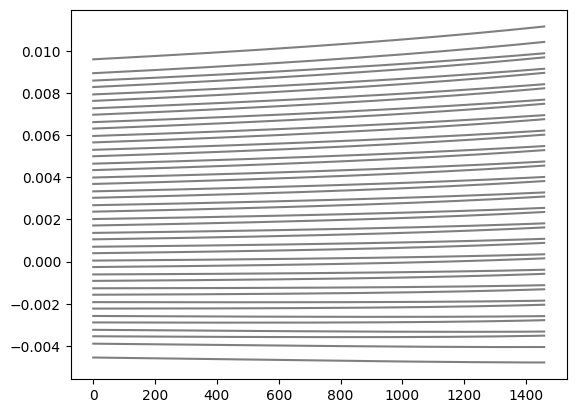

In [302]:
plt.plot(all_inputs[0, :, :, 2].T, alpha=0.5, c="k")

In [303]:
tf = generator(all_inputs, y_lms=ylms, parameters_response=parameters_response)

In [304]:
# %timeit tf = generator(all_inputs, y_lms=ylms, parameters_response=parameters_response)

In [305]:
tf.shape

(1, 1460, 2161, 3)

In [306]:
# all_inputs[0,-1,1144,:]

In [307]:
# all_inputs[0,:,1145,:]

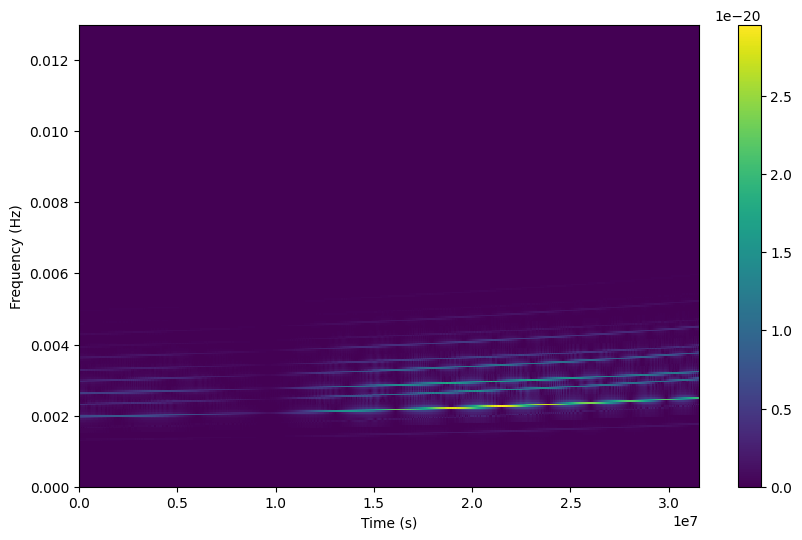

In [308]:
plt.figure(figsize=(10, 6))
plt.pcolormesh(
    generator.t_tranche,
    generator.f_tranche,
    np.abs((tf[0, :, :, 0]).T),
)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 1.3e-2)
plt.colorbar()

In [20]:
psd_tmp = np.ones((nT, nF, 2), dtype=np.float64)  # * 1e-34